# Figure 1

LSV

run at /vento (USP)

Created: 27/01/2025 

Last update: 05/06/2026 

In [1]:
import sys
sys.prefix
import numpy as np # type: ignore
import xarray as xr # type: ignore
import os, glob
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib.dates as mdates # type: ignore
import matplotlib.ticker as ticker # type: ignore
import matplotlib.patches as mpatches  # type: ignore
from matplotlib.gridspec import GridSpec # type: ignore
import matplotlib.patches as patches
import cartopy.crs as ccrs # type: ignore
import cartopy.feature as cfeature # type: ignore
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER # type: ignore
import cmaps # type: ignore
from cmocean import cm # type: ignore
from shapely.geometry.polygon import LinearRing # type: ignore
from scipy import integrate # type: ignore
from scipy import stats # type: ignore
from scipy import signal # type: ignore
from scipy.stats import pearsonr # type: ignore
from scipy.stats import ttest_ind # type: ignore
import seaborn as sns # type: ignore
import cftime # type: ignore
import nc_time_axis # type: ignore
degree_sign= u'\N{DEGREE SIGN}'

In [2]:
def plotMapNoCont(i,j,lon1,lon2,lat1,lat2, interv_lat, interv_lon):
    #Set the projection information
    proj = ccrs.PlateCarree()
    #Create a figure with an axes object on which we will plot. Pass the projection to that axes.
    fig, Ax = plt.subplots(nrows=i,ncols=j, figsize=(8, 4), subplot_kw=dict(projection=proj))
    fig.subplots_adjust(hspace=.25)

    if(i==1 and j==1):
        AX=np.array([Ax])
    else:
        AX=Ax.flatten()

    for ax in (AX[:]):
        # set the map limits
        ax.set_extent([lon1, lon2, lat1, lat2],crs=ccrs.PlateCarree())
        ax.coastlines('50m',linewidth=1, zorder=101)
        ax.add_feature(cfeature.LAND, zorder=100, edgecolor='k',facecolor='white')  
        
            # === Add thin boundary frame ===
        rect = patches.Rectangle(
        (0, 0), 1, 1,                   # full axes
        linewidth=0.8,                  # adjust thickness here
        edgecolor='black',
        facecolor='none',
        transform=ax.transAxes,         # IMPORTANT: axes coords, not data coords
        zorder=300
        )
        ax.add_patch(rect)

        #Add lat/lon gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=.5, linestyle=':',color='black') 
        gl.top_labels = False
        gl.bottom_labels = True
        gl.right_labels = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xlines = False
        gl.ylines = False
        gl.xlocator = ticker.FixedLocator(np.arange(lon1,lon2,interv_lon))
        gl.ylocator = ticker.FixedLocator(np.arange(lat1,lat2,interv_lat))
        gl.xlabel_style = {'size': 12 }
        gl.ylabel_style = {'size': 12 }

    return fig, Ax

In [3]:
def xr_CI(data_array, signif=0.95, dim=None):
    from scipy.stats import t # type: ignore
    """
    Calculate the confidence interval of a DataArray along a specified dimension.

    Parameters:
    data_array (xarray.DataArray): The DataArray to compute the confidence interval on.
    confidence (float): The confidence level, between 0 and 1. Default is 0.95.
    dim (str or None): The dimension along which to calculate the confidence interval. 
                       If None, will compute over the entire dataset.

    Returns:
    xarray.DataArray: A DataArray containing the lower and upper bounds of the confidence interval.
    """
    mean = data_array.mean(dim)
    std = data_array.std(dim)
    n = data_array.count(dim)
    se = std / np.sqrt(n)
    h = se * t.ppf((1 + signif) / 2., n - 1)

    lower_bound = mean - h
    upper_bound = mean + h
    return xr.Dataset({'lb': lower_bound, 'ub': upper_bound})

In [4]:
def stippling_signal_agreement(data,nivel):
    #data = tosMod #np.stack(mv_std_modelos)
    nPos=np.sum(data>=0, axis=-1) # check where the anomaly is positive (sum)
    nNeg=np.sum(data<0, axis=-1) # check where the anomaly is negative
    N = round(data.shape[1]*nivel*.01) # calculates the number of events for reference
    
    if data.dims[0] == 'time':
        scatter_x=data.time[(nPos>=N)+(nNeg>=N)] # create dots to plot (time vs. anomaly)
    elif data.dims[0] == 'year':
        scatter_x=data.year[(nPos>=N)+(nNeg>=N)] # create dots to plot (time vs. anomaly)
    if data.dims[1] == 'ensemble':
        scatter_y=data.mean('ensemble')[(nPos>=N)+(nNeg>=N)]
    elif data.dims[1] == 'record':
        scatter_y=data.mean('record')[(nPos>=N)+(nNeg>=N)]
    
    return scatter_x, scatter_y

In [5]:
def calculate_linear_trend(values): # for variable with time not year
    # Calculate linear fit coefficients
    coeffs = np.polyfit(values.time, values.values, 1)
    slope, intercept = coeffs

    # Predict values using the linear model
    model_predictions = np.polyval([slope, intercept], values.time)

    # Calculate residuals and statistical measures
    residuals = values.values - model_predictions
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((values.values - np.mean(values.values))**2)
    r_squared = 1 - (ss_res / ss_tot)
    degrees_of_freedom = len(values) - 2
    stderr = np.sqrt(ss_res / degrees_of_freedom) / np.sqrt(np.sum((values.time - np.mean(values.time))**2))
    t_stat = slope / stderr
    p_value = stats.t.sf(np.abs(t_stat), degrees_of_freedom) * 2  # two-tailed p-value

    # Output the results
    trend_line = slope * values.time + intercept
    print(f"Linear trend: slope = {slope:.3f} (units/year), intercept = {intercept:.3f}")
    print(f"R-squared: {r_squared:.3f}, p-value: {p_value:.3g}")

    return slope, intercept, r_squared, p_value, trend_line

In [6]:
# regressao ponto a ponto de um vetor xin com uma matriz 3D y ao longo de eixo 0 de y
def reg1x3(xin,y):
    n=len(xin)
    x=np.broadcast_to(xin[:,np.newaxis,np.newaxis],(n,y.shape[1],y.shape[2]))    
    xmean,ymean=x.mean(axis=0),y.mean(axis=0)
    xmean,ymean=np.broadcast_to(xmean[np.newaxis,:,:],(n,y.shape[1],y.shape[2])),np.broadcast_to(ymean[np.newaxis,:,:],(n,y.shape[1],y.shape[2]))
    slope=np.sum((x-xmean)*(y-ymean),axis=0)/np.sum((x-xmean)**2,axis=0)
    intercept=y.sum(axis=0)/n - slope*x.sum(axis=0)/n
    R=slope*x.std(axis=0)/y.std(axis=0)
    y_est=intercept+slope*x
    stderr =  np.sqrt( np.sum((y-y_est)**2,axis=0) /(n-2)  )
    tstat=R*np.sqrt(n-2)/np.sqrt(1-R*R)
    from scipy.stats import t # type: ignore
    pvalue=t.sf(np.abs(tstat), n-1)*2
    return slope,pvalue

In [7]:
PathDataSets = '/bolha/wk2/laura/dataIPSLpast2k/'
PathDataSetsRaw = '/bolha/wk2/IPSLpast2k/'
PathFigures = '/home/laura/figures/STC/draft_figures/review1/'

In [8]:
slice_clim =slice('1850','1900')
clim_ref = '1850-1900'

In [10]:
plt.rcParams['font.size'] = 14

## * SST and TAU time series

In [11]:
dsSST = xr.open_dataset(PathDataSets+'thetao/thetao_Omon_AtlSfc_CM65-LR-past2k-all_gr_050001-201412.nc')
dsTAUU = xr.open_dataset(PathDataSetsRaw+'tauu/tauu_Amon_CM65-LR-past2k-members-1-10_gr_050001-201412.nc')


In [12]:
# SST 
anomSST = dsSST.groupby('time.month') - dsSST.sel(time=slice_clim).groupby('time.month').mean('time')
NTA = anomSST.sel(lat=slice(15,5),lon=slice(-50,-20)).mean(dim=['lat','lon'])
STA = anomSST.sel(lat=slice(-15,-25),lon=slice(-25,5)).mean(dim=['lat','lon'])

NTAyr = NTA.groupby('time.year').mean('time').rename({'year': 'time'})
STAyr = STA.groupby('time.year').mean('time').rename({'year': 'time'})

NTAyrSMOOTH = NTAyr.rolling(time=10).mean().rolling(time=10).mean()
STAyrSMOOTH = STAyr.rolling(time=10).mean().rolling(time=10).mean()
NTAyrSMOOTH_conf = xr_CI(NTAyrSMOOTH.thetao, signif=0.95, dim='record')
STAyrSMOOTH_conf = xr_CI(STAyrSMOOTH.thetao, signif=0.95, dim='record')

# trends 1850-2015
NTAslope, NTAintercept, NTAr_squared, NTAp_value, NTAtrend_line = calculate_linear_trend(NTAyrSMOOTH.mean('record').thetao.sel(time=slice(1850,2015)).dropna(dim='time') )
STAslope, STAintercept, STAr_squared, STAp_value, STAtrend_line = calculate_linear_trend(STAyrSMOOTH.mean('record').thetao.sel(time=slice(1850,2015)).dropna(dim='time') )

val1850 = NTAtrend_line.sel(time=1850, method="nearest")
val2015 = NTAtrend_line.sel(time=2015, method="nearest")
print(f"NTA Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta_thetao = val2015 - val1850
print(f"Absolute change in NTA SST from 1850 to 2015: {delta_thetao.values}")

val1850 = STAtrend_line.sel(time=1850, method="nearest")
val2015 = STAtrend_line.sel(time=2015, method="nearest")
print(f"STA Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta_thetao = val2015 - val1850
print(f"Absolute change in STA SST from 1850 to 2015: {delta_thetao.values}")

Linear trend: slope = 0.007 (units/year), intercept = -12.690
R-squared: 0.919, p-value: 7.24e-91
Linear trend: slope = 0.003 (units/year), intercept = -6.253
R-squared: 0.762, p-value: 1.12e-52
NTA Value 1850: -0.24496497746952173, value 2015 0.8582450144021117
Absolute change in NTA SST from 1850 to 2015: 1.1032099918716334
STA Value 1850: -0.14742308431874385, value 2015 0.3938475994146815
Absolute change in STA SST from 1850 to 2015: 0.5412706837334254


In [13]:
# trends 1920-2015
shortNTAslope, shortNTAintercept, shortNTAr_squared, shortNTAp_value, shortNTAtrend_line2 = calculate_linear_trend(NTAyrSMOOTH.mean('record').thetao.sel(time=slice(1920,2015)).dropna(dim='time') )
shortSTAslope, shortSTAintercept, shortSTAr_squared, shortSTAp_value, shortSTAtrend_line2 = calculate_linear_trend(STAyrSMOOTH.mean('record').thetao.sel(time=slice(1920,2015)).dropna(dim='time') )

val1850 = shortNTAtrend_line2.sel(time=1920, method="nearest")
val2015 = shortNTAtrend_line2.sel(time=2015, method="nearest")
print(f"NTA Value 1920: {val1850.values}, value 2015 {val2015.values}")
delta_thetao = val2015 - val1850
print(f"Absolute change in NTA SST from 1920 to 2015: {delta_thetao.values}")

val1850 = shortSTAtrend_line2.sel(time=1920, method="nearest")
val2015 = shortSTAtrend_line2.sel(time=2015, method="nearest")
print(f"STA Value 1920: {val1850.values}, value 2015 {val2015.values}")
delta_thetao = val2015 - val1850
print(f"Absolute change in STA SST from 1920 to 2015: {delta_thetao.values}")


Linear trend: slope = 0.009 (units/year), intercept = -16.915
R-squared: 0.898, p-value: 7.3e-48
Linear trend: slope = 0.005 (units/year), intercept = -9.783
R-squared: 0.697, p-value: 7.81e-26
NTA Value 1920: 0.11658817059116089, value 2015 0.9504258249935411
Absolute change in NTA SST from 1920 to 2015: 0.8338376544023802
STA Value 1920: -0.020845282656186015, value 2015 0.45707633553171156
Absolute change in STA SST from 1920 to 2015: 0.4779216181878976


In [14]:
# TAUU
anomTAUU = dsTAUU.groupby('time.month') - dsTAUU.sel(time=slice_clim).groupby('time.month').mean('time')
NTAtauu = anomTAUU.sel(lat=slice(5,15),lon=slice(-50,-20)).mean(dim=['lat','lon'])
STAtauu = anomTAUU.sel(lat=slice(-25,-15),lon=slice(-25,5)).mean(dim=['lat','lon'])

NTAyrTAUU = NTAtauu.groupby('time.year').mean('time').rename({'year': 'time'})
STAyrTAUU = STAtauu.groupby('time.year').mean('time').rename({'year': 'time'})

NTAyrSMOOTHtauu = NTAyrTAUU.rolling(time=10).mean().rolling(time=10).mean()
STAyrSMOOTHtauu = STAyrTAUU.rolling(time=10).mean().rolling(time=10).mean()
NTAyrSMOOTHtauu_conf = xr_CI(NTAyrSMOOTHtauu.tauu, signif=0.95, dim='ensemble')
STAyrSMOOTHtauu_conf = xr_CI(STAyrSMOOTHtauu.tauu, signif=0.95, dim='ensemble')

# trends 1850-2015 
tauuNTAslope, tauuNTAintercept, tauuNTAr_squared, tauuNTAp_value, tauuNTAtrend_line = calculate_linear_trend(NTAyrSMOOTHtauu.mean('ensemble').tauu.sel(time=slice(1850,2015)).dropna(dim='time') )
tauuSTAslope, tauuSTAintercept, tauuSTAr_squared, tauuSTAp_value, tauuSTAtrend_line = calculate_linear_trend(STAyrSMOOTHtauu.mean('ensemble').tauu.sel(time=slice(1850,2015)).dropna(dim='time') )

val1850 = tauuNTAtrend_line.sel(time=1850, method="nearest")
val2015 = tauuNTAtrend_line.sel(time=2015, method="nearest")
print(f"NTA TAUU Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in NTSA TAUU from 1850 to 2015: {delta.values}")

val1850 = tauuSTAtrend_line.sel(time=1850, method="nearest")
val2015 = tauuSTAtrend_line.sel(time=2015, method="nearest")
print(f"STA TAUU Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in STA TAUU from 1850 to 2015: {delta.values}")


Linear trend: slope = 0.000 (units/year), intercept = -0.056
R-squared: 0.937, p-value: 1.3e-99
Linear trend: slope = -0.000 (units/year), intercept = 0.023
R-squared: 0.654, p-value: 2.09e-39
NTA TAUU Value 1850: -0.0010827729105321593, value 2015 0.0038231325938779745
Absolute change in NTSA TAUU from 1850 to 2015: 0.004905905504410134
STA TAUU Value 1850: 0.00015439144793522735, value 2015 -0.0018621333625538604
Absolute change in STA TAUU from 1850 to 2015: -0.0020165248104890877


In [15]:
# trends 1920-2015
short_tauuNTAslope, short_tauuNTAintercept, short_tauuNTAr_squared, short_tauuNTAp_value, short_tauuNTAtrend_line2 = calculate_linear_trend(NTAyrSMOOTHtauu.mean('ensemble').tauu.sel(time=slice(1920,2015)).dropna(dim='time') )
short_tauuSTAslope, short_tauuSTAintercept, short_tauuSTAr_squared, short_tauuSTAp_value, short_tauuSTAtrend_line2 = calculate_linear_trend(STAyrSMOOTHtauu.mean('ensemble').tauu.sel(time=slice(1920,2015)).dropna(dim='time') )

val1850 = short_tauuNTAtrend_line2.sel(time=1920, method="nearest")
val2015 = short_tauuNTAtrend_line2.sel(time=2015, method="nearest")
print(f"NTA TAUU Value 1920: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in NTSA TAUU from 1920 to 2015: {delta.values}")

val1850 = short_tauuSTAtrend_line2.sel(time=1920, method="nearest")
val2015 = short_tauuSTAtrend_line2.sel(time=2015, method="nearest")
print(f"STA TAUU Value 1920: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in STA TAUU from 1920 to 2015: {delta.values}")


Linear trend: slope = 0.000 (units/year), intercept = -0.072
R-squared: 0.914, p-value: 2.91e-51
Linear trend: slope = -0.000 (units/year), intercept = 0.023
R-squared: 0.737, p-value: 1e-28
NTA TAUU Value 1920: 0.0006294793004072985, value 2015 0.004166902730800157
Absolute change in NTSA TAUU from 1920 to 2015: 0.003537423430392858
STA TAUU Value 1920: -0.0007595303772847603, value 2015 -0.0019198438706026603
Absolute change in STA TAUU from 1920 to 2015: -0.0011603134933179


## * SST and TAU spatial trend

In [16]:
dsSST = xr.open_dataset(PathDataSets+'thetao/thetao_Omon_AtlSfc_CM65-LR-past2k-all_gr_050001-201412.nc')
dsTAUU = xr.open_dataset(PathDataSetsRaw+'tauu/tauu_Amon_CM65-LR-past2k-members-1-10_gr_050001-201412.nc')
ipslTAUUsel = dsTAUU.sel(lon=slice(-65, 25),lat=slice(-35,35))

In [17]:
# annual avgs
slice_hist = slice('1850','2015')
sst = dsSST.coarsen(time=12).mean().thetao.sel(time=slice_hist).mean('record')
tauu = ipslTAUUsel.coarsen(time=12).mean().tauu.sel(time=slice_hist).mean('ensemble')

# climatology avg (1850-1900)
climSST = dsSST.sel(time=slice_clim).mean(dim=['time','record'])
climTAUU = ipslTAUUsel.sel(time=slice_clim).mean(dim=['time','ensemble'])

In [18]:
# trends maps (1850-2015)
slope_sst,pv_sst = reg1x3(np.arange(sst.shape[0]),sst.values)
slope_sst_sig = slope_sst
slope_sst_sig[pv_sst>=0.05]=0

slope_tauu,pv_tauu = reg1x3(np.arange(tauu.shape[0]),tauu.values)
slope_tauu_sig = slope_tauu
slope_tauu_sig[pv_tauu>=0.05]=0

## Figure series

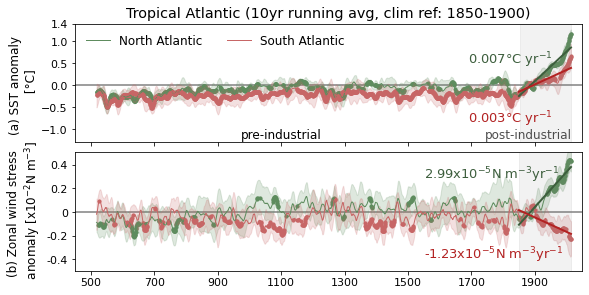

In [34]:
colorTNA = '#5E8C5E'
colorTSA = '#C76666'


plt.rcParams.update({"font.size": 12, "xtick.labelsize": 11, "ytick.labelsize": 11,})
fig, ax = plt.subplots(2,1,figsize=(8, 4), sharex=True,constrained_layout=True) 
ax[0].set_title('Tropical Atlantic (10yr running avg, clim ref: '+clim_ref+')')

########## SST ANOMALY
ax[0].set_ylabel('(a) SST anomaly \n ['+degree_sign+'C]')
ax[0].axhline(y=0,color='gray',zorder=0.6)

# north atlantic
ax[0].fill_between(range(500,2015), NTAyrSMOOTH_conf.lb, NTAyrSMOOTH_conf.ub, color=colorTNA, alpha=.2, zorder=1)
ax[0].plot(range(500,2015), NTAyrSMOOTH.mean('record').thetao ,c=colorTNA,lw=1, zorder=3, label='North Atlantic')
ax[0].plot(range(1850,2015), NTAtrend_line, color='#3D5E3D',lw=2, zorder=4)
ax[0].text(1690, .5, f"{round(NTAslope, 3)}{degree_sign}C yr$^{{-1}}$", color='#3D5E3D', fontsize=13)
x,y = stippling_signal_agreement(NTAyrSMOOTH.thetao,80) # ensemble members agrement
ax[0].scatter(x[1:],y[1:], color=colorTNA, marker='o', s=10, edgecolors=colorTNA) # stippling where the anomaly agrees on signal

# south atlantic
ax[0].fill_between(range(500,2015), STAyrSMOOTH_conf.lb, STAyrSMOOTH_conf.ub, color=colorTSA, alpha=.2, zorder=1)
ax[0].plot(range(500,2015), STAyrSMOOTH.mean('record').thetao ,c=colorTSA,lw=1, zorder=3, label='South Atlantic')
ax[0].plot(range(1850,2015), STAtrend_line, color='firebrick',lw=2, zorder=4)
ax[0].text(1690, -0.85, f"{round(STAslope, 3)}{degree_sign}C yr$^{{-1}}$", color='firebrick', fontsize=13)
x,y = stippling_signal_agreement(STAyrSMOOTH.thetao,80) # ensemble members agrement
ax[0].scatter(x[1:],y[1:], color=colorTSA, marker='o', s=10, edgecolors=colorTSA) # stippling where the anomaly agrees on signal
ax[0].legend(frameon=False, loc='upper left', ncol=2)

ax[0].set_ylim(-1.3,1.4)
ax[0].set_yticks([-1,-0.5,0,0.5,1,1.4])
ax[0].set_xlim(450,2050)
ax[0].set_xticks(np.arange(500,2014,100))
ax[0].text(1100,-1.2,'pre-industrial',color='k',ha='center')
ax[0].axvspan(1852, 2015, alpha=0.1, color='gray')
ax[0].text(1880,-1.2,'post-industrial',color='#4D4D4D',ha='center')


########## WIND STRESS 
ax[1].set_ylabel('(b) Zonal wind stress \n anomaly [x10$^{-2}$N m$^{{-3}}$]')
ax[1].axhline(y=0,color='gray',zorder=0.6)

# north atlantic
ax[1].fill_between(range(500,2015), NTAyrSMOOTHtauu_conf.lb, NTAyrSMOOTHtauu_conf.ub, color=colorTNA, alpha=.2, zorder=1)
ax[1].plot(range(500,2015), NTAyrSMOOTHtauu.mean('ensemble').tauu ,c=colorTNA,lw=1, zorder=3, label='North Atlantic')
ax[1].plot(range(1850,2015), tauuNTAtrend_line, color='#3D5E3D',lw=2, zorder=4)
ax[1].text(1550, .0028, f"{round(tauuNTAslope*10**5, 2)}x10$^{{-5}}$N m$^{{-3}}$yr$^{{-1}}$", color='#3D5E3D', fontsize=13)
x,y = stippling_signal_agreement(NTAyrSMOOTHtauu.tauu,80) # ensemble members agrement
ax[1].scatter(x[1:],y[1:], color=colorTNA, marker='o', s=10, edgecolors=colorTNA) # stippling where the anomaly agrees on signal

# south atlantic
ax[1].fill_between(range(500,2015), STAyrSMOOTHtauu_conf.lb, STAyrSMOOTHtauu_conf.ub, color=colorTSA, alpha=.2, zorder=1)
ax[1].plot(range(500,2015), STAyrSMOOTHtauu.mean('ensemble').tauu ,c=colorTSA,lw=1, zorder=3, label='South Atlantic')
ax[1].plot(range(1850,2015), tauuSTAtrend_line, color='firebrick',lw=2, zorder=4)
ax[1].text(1550, -0.004, f"{round(tauuSTAslope*10**5, 2)}x10$^{{-5}}$N m$^{{-3}}$yr$^{{-1}}$", color='firebrick', fontsize=13)
x,y = stippling_signal_agreement(STAyrSMOOTHtauu.tauu,80) # ensemble members agrement
ax[1].scatter(x[1:],y[1:], color=colorTSA, marker='o', s=10, edgecolors=colorTSA) # stippling where the anomaly agrees on signal

ax[1].set_ylim(-0.005,0.0051)
ax[1].set_yticks([-0.004,-0.002,0,0.002,0.004])
ax[1].set_yticklabels(['-0.4','-0.2','0','0.2','0.4'])
ax[1].set_xlim(450,2050)
ax[1].set_xticks(np.arange(500,2014,200))
_ = ax[1].axvspan(1850, 2014, alpha=0.1, color='gray')

fig.savefig(PathFigures+'/partialfig_time_series_SST_windStress.png', format='png', bbox_inches='tight', dpi=300,   facecolor='white')

## Figure maps

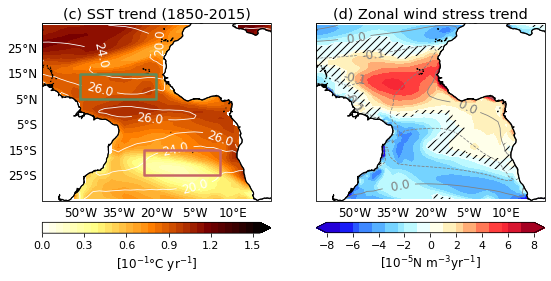

In [19]:
fig, axes = plotMapNoCont(1, 2, -65, 25, -35, 35, 10, 15)
fig.set_figwidth(9)
plt.rcParams.update({"font.size": 12, "xtick.labelsize": 11, "ytick.labelsize": 11,})
ax_right = axes[1]
gl = ax_right._gridliners[0]
gl.left_labels = False 

##### SST
axes[0].set_title('(c) SST trend (1850-2015)')
mask = pv_sst < 0.05
mask_nonsig_sst = pv_sst >= 0.05
cf0 = axes[0].contourf(sst.lon,
                 sst.lat,
                 #slope_sst_sig*12*10, # deg/month to deg/year
                 slope_sst*12*10, # deg/month to deg/year
                 cmap=cmaps.MPL_afmhot_r, 
                 levels=np.arange(0,1.6,0.05),
                 zorder=.6,
                 extend='max')
axes[0].contourf(
    sst.lon, sst.lat,
    mask_nonsig_sst,
    levels=[0.5, 1],
    hatches=['///'],     
    colors='none',   
    zorder=1.5)
contour_lines = axes[0].contour(climSST.lon,
                           climSST.lat,
                           climSST.thetao, 
                           colors='white',
                           linewidths=.8,
                           levels=[20,24,26])
axes[0].clabel(contour_lines, fmt='%2.1f', colors='white', fontsize=12)
cbar = fig.colorbar(cf0, ax=axes[0], orientation='horizontal',fraction=0.05,pad=0.099)
cbar.set_label('[10$^{-1}$' + degree_sign + 'C yr$^{{-1}}$]')
cbar.set_ticks(np.arange(0, 1.6, 0.3))


##### ZONAL WIND STRESS
axes[1].set_title('(d) Zonal wind stress trend')
mask = pv_sst < 0.05
mask_nonsig_tauu = pv_tauu >= 0.05
cf1 = axes[1].contourf(tauu.lon,
                 tauu.lat,
                 #slope_tauu_sig*12*10000, # deg/month to deg/year
                 slope_tauu*12*10000, # deg/month to deg/year
                 cmap=cmaps.BlueDarkRed18, 
                 levels=np.arange(-8,8.1,0.5),
                 zorder=.6,
                 extend='both')
axes[1].contourf(
    tauu.lon, tauu.lat,
    mask_nonsig_tauu,
    levels=[0.5, 1],
    hatches=['///'],     
    colors='none',   
    zorder=1.5)
contour_lines = axes[1].contour(climTAUU.lon,
                           climTAUU.lat,
                           climTAUU.tauu, 
                           colors='gray',
                           linewidths=.8)
axes[1].clabel(contour_lines, fmt='%4.1f', colors='gray', fontsize=12)
cbar = fig.colorbar(cf1, ax=axes[1], orientation='horizontal',fraction=0.05,pad=0.099)
cbar.set_label('[10$^{{-5}}$N m$^{{-3}}$yr$^{{-1}}$]')
cbar.set_ticks(np.arange(-8, 8.1, 2))


##### BOXES
# North Atlantic
lons = [-20, -50, -50, -20]
lats = [15,15,5,5]
ring = LinearRing(list(zip(lons, lats)))
axes[0].add_geometries([ring], ccrs.PlateCarree(), facecolor='none', edgecolor='#5E8C5E', lw=2.5, zorder=300)
#axes[1].add_geometries([ring], ccrs.PlateCarree(), facecolor='none', edgecolor='#5E8C5E', lw=2.5, zorder=300)
# South Atlantic
lons = [-25, 5, 5, -25]
#lons = [-35, -5, -5, -35]
lats = [-25,-25,-15,-15]
ring = LinearRing(list(zip(lons, lats)))
_=axes[0].add_geometries([ring], ccrs.PlateCarree(), facecolor='none', edgecolor='#C76666', lw=2.5, zorder=300)
#_=axes[1].add_geometries([ring], ccrs.PlateCarree(), facecolor='none', edgecolor='#C76666', lw=2.5, zorder=300)

fig.savefig(PathFigures+'/partialfig_maps_trend_SST_windStress.png', format='png', bbox_inches='tight', dpi=300, facecolor='white')